In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-07 02:35:26.924 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.experts.tapas import lock_left as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 3, 4, 5]

2026-07-07 02:35:28.876 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-07 02:35:31.112 | INFO     | heca.misc.logger:info:30 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_left_button
2026-07-07 02:35:31.112 | INFO     | tapas_gmm_modified.utils.logging:wrapper:67 - Initializing Policy:
2026-07-07 02:35:31.112 | INFO     | tapas_gmm_modified.encoder:get_image_encoder_class:62 - No encoder config provided. Using None.
2026-07-07 02:35:31.113 | WARNING  | heca.misc.logger:warning:26 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_left_button/policy_gt.pt
GMMPolicy(
  (obs_encoder): ObservationEncoder()
)
[[0, 2], [2, 7]]


In [3]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


2026-07-07 02:35:49.135 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 36 using strategy mean-length.
n_trajs 5
n_frames 8


('ee_init',
 'block_0',
 'button_0',
 'button_1',
 'drawer_handle',
 'window_handle',
 'block_0_target',
 'ee_target')

2026-07-07 02:35:49.159 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:35:49.159 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:49.159 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


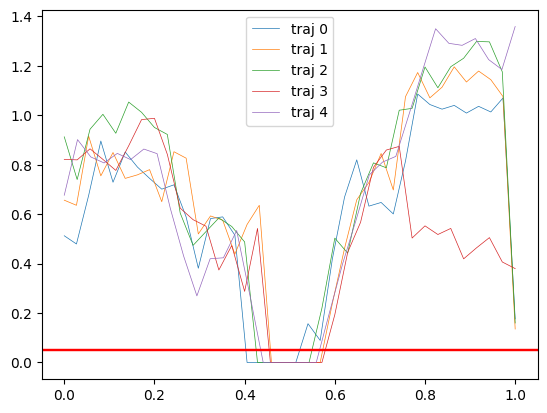

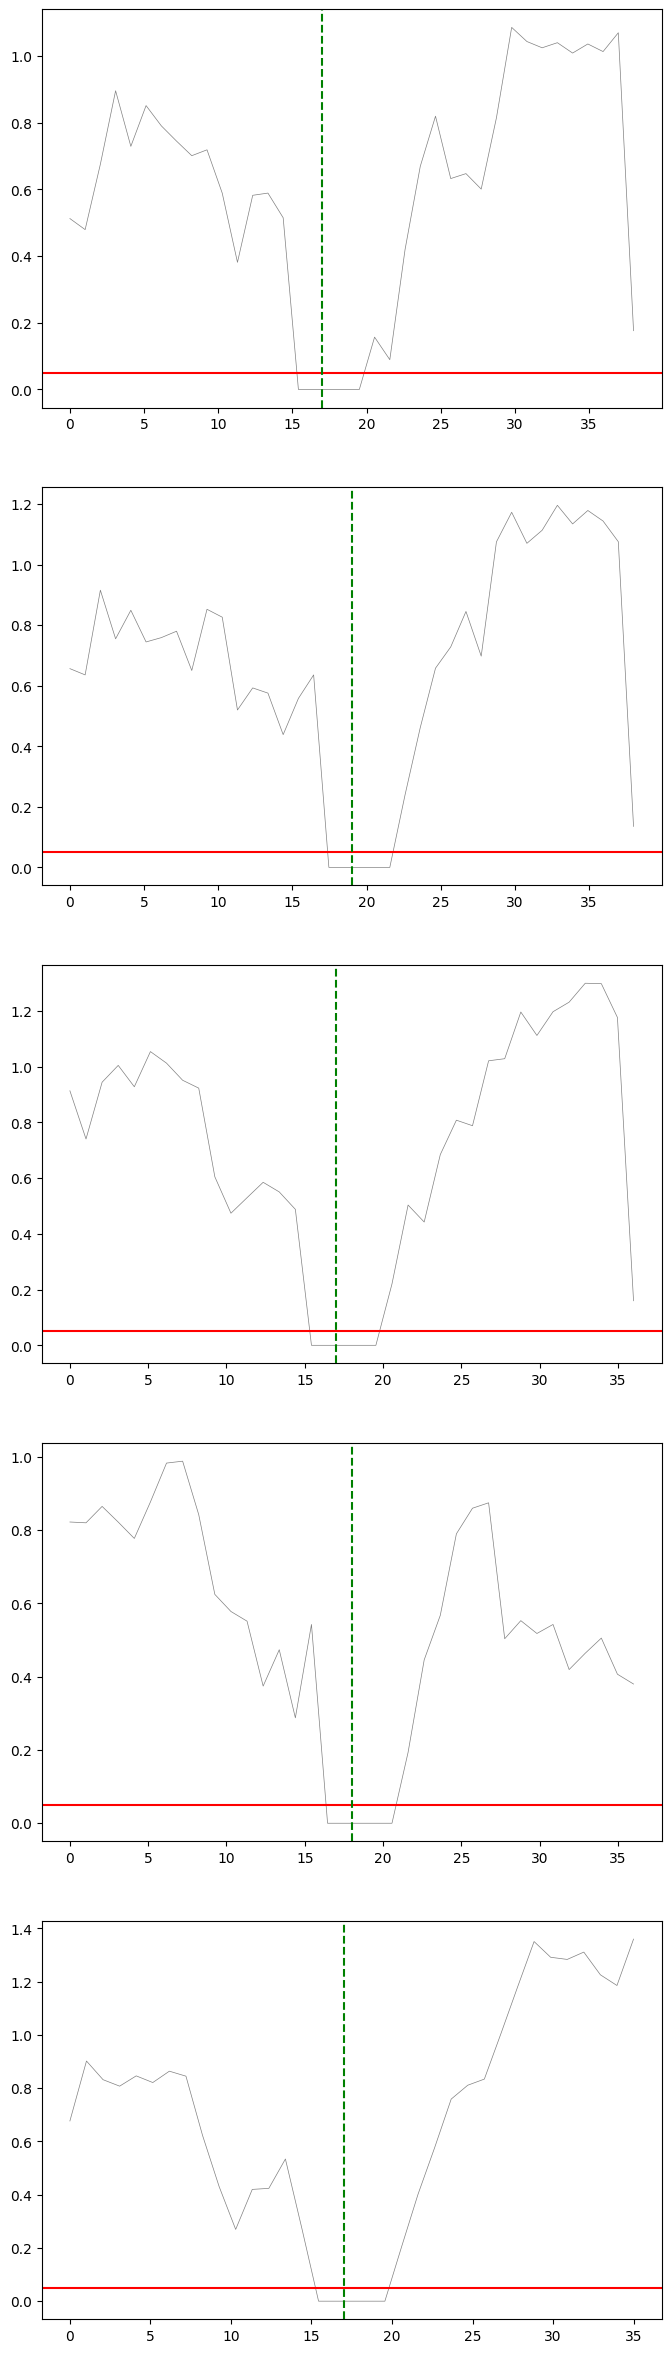

2026-07-07 02:35:49.582 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:35:49.583 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 02:35:49.583 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:35:49.587 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 19 using strategy mean-length.
2026-07-07 02:35:49.587 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 2 segments
2026-07-07 02:35:49.587 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 1/8
2026-07-07 02:35:49.587 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:49.587 | INFO     | tapas_gmm_modified.dataset.demos:subsample_t

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:49.682 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-07-07 02:35:49.682 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:49.683 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 02:35:49.685 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:35:49.686 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:49.686 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:49.686 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:49.733 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-07-07 02:35:49.733 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:49.733 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 02:35:49.736 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:35:49.736 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:49.736 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:49.736 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-07-07 02:35:50.890 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:35:50.891 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:50.891 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:50.891 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:51.047 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:35:51.047 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:35:51.047 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:51.047 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/10 [00:00<?, ?it/s]

((array([[5.06e+012, 1.22e+013, 2.43e+012, 3.60e+010, 2.39e+007, 6.01e+002,
          3.55e-004, 1.75e-010, 5.51e-018, 3.58e-025, 6.63e-031, 5.31e-036,
          3.69e-043, 4.79e-051, 2.70e-058, 1.64e-064, 5.42e-072, 8.94e+012,
          1.34e+013, 1.39e+012, 1.37e+010, 7.14e+006, 3.21e-002, 8.08e-008,
          4.59e-016, 7.16e-026, 1.70e-035, 1.09e-043, 4.44e-051, 1.49e-061,
          5.40e-071, 3.01e-079, 1.45e-085, 1.86e-092, 7.00e+012, 1.16e+013,
          2.06e+012, 7.82e+009, 2.15e+006, 9.79e-001, 5.59e-008, 6.94e-016,
          5.61e-024, 1.63e-030, 1.09e-035, 5.35e-041, 3.44e-047, 9.45e-054,
          2.44e-060, 4.61e-066, 3.76e-073, 6.12e+012, 1.01e+013, 1.97e+011,
          3.66e+007, 6.44e+001, 1.96e-007, 4.01e-018, 2.18e-030, 1.08e-042,
          2.68e-065, 4.11e-078, 7.22e-090, 1.82e-101, 1.04e-111, 8.88e-122,
          1.54e-131, 6.37e-138, 5.65e+012, 8.88e+012, 2.81e+011, 1.35e+008,
          1.23e+003, 5.57e-004, 2.70e-013, 3.82e-023, 1.52e-032, 5.49e-041,
          6.

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


2026-07-07 02:35:51.237 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.304 | WARNING  | tapas_gmm_modified.viz.gmm

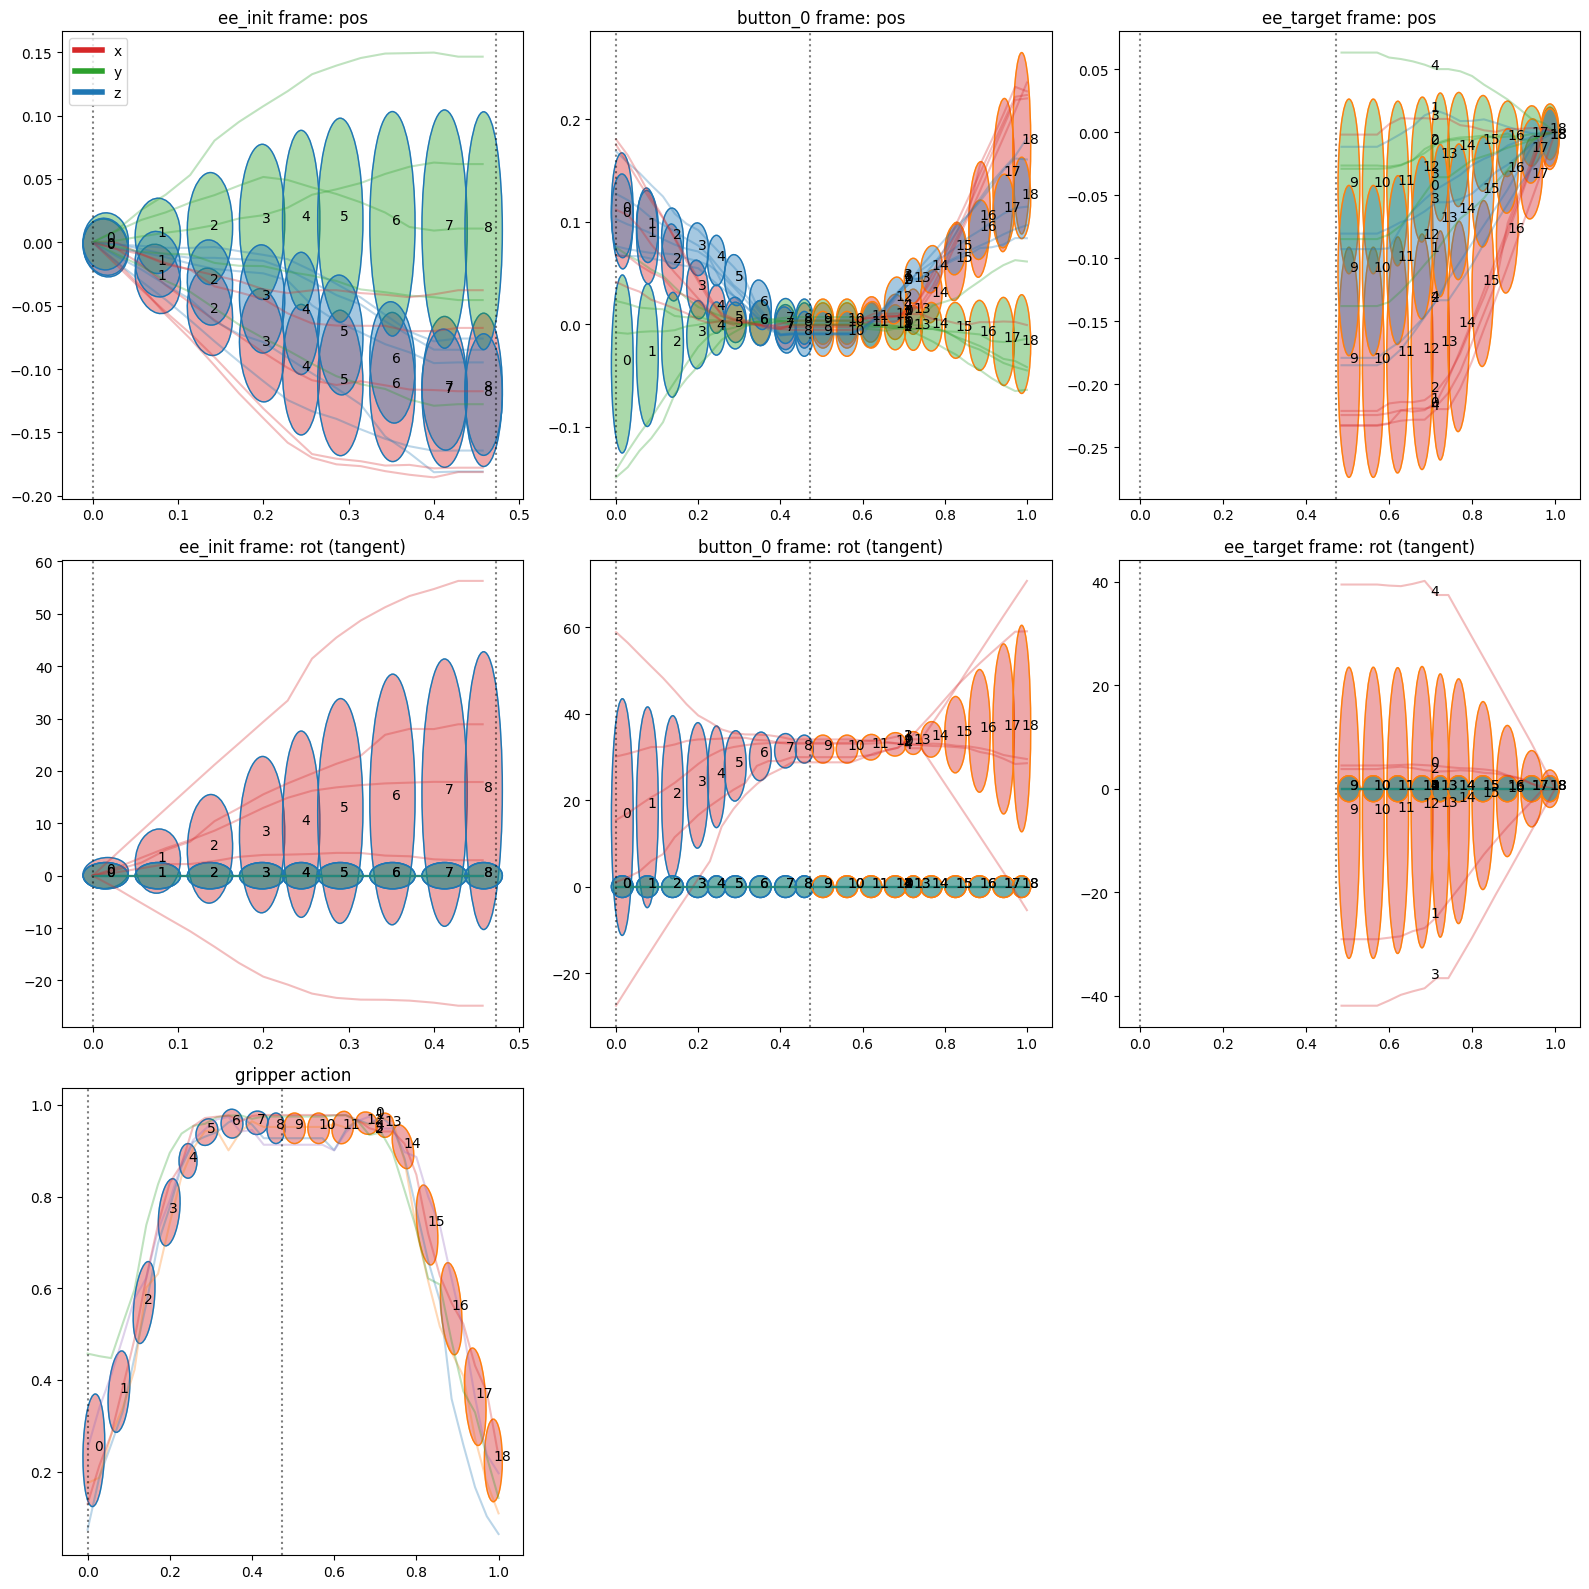

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


2026-07-07 02:35:53.557 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:35:53.557 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-07 02:35:53.560 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:35:53.560 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:35:53.564 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:35:53.600 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:36:06.764 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 02:36:06.796 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:36:06.797 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:36:06.799 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:36:06.824 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:36:17.237 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged


((array([[1.00e+000, 9.69e-001, 9.37e-002, 5.62e-007, 7.47e-022, 5.75e-051,
          3.14e-095, 1.70e-155, 4.20e-233, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000,
          9.89e-001, 6.67e-002, 9.27e-010, 2.09e-030, 3.35e-068, 1.20e-124,
          1.36e-201, 6.65e-301, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 9.78e-001,
          5.68e-002, 9.77e-008, 2.16e-023, 7.51e-053, 7.57e-097, 1.39e-156,
          5.59e-232, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 9.96e-001, 1.44e-003,
          2.38e-014, 4.06e-038, 7.07e-085, 1.19e-161, 6.97e-271, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 9.97e-001, 2.29e-003, 1.47e-021,
          2.69e-063, 5.41e-128, 1.25e-213, 0.00e+000, 0.00e+000, 0.00e+000,
          0.

2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:36:17.326 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippi

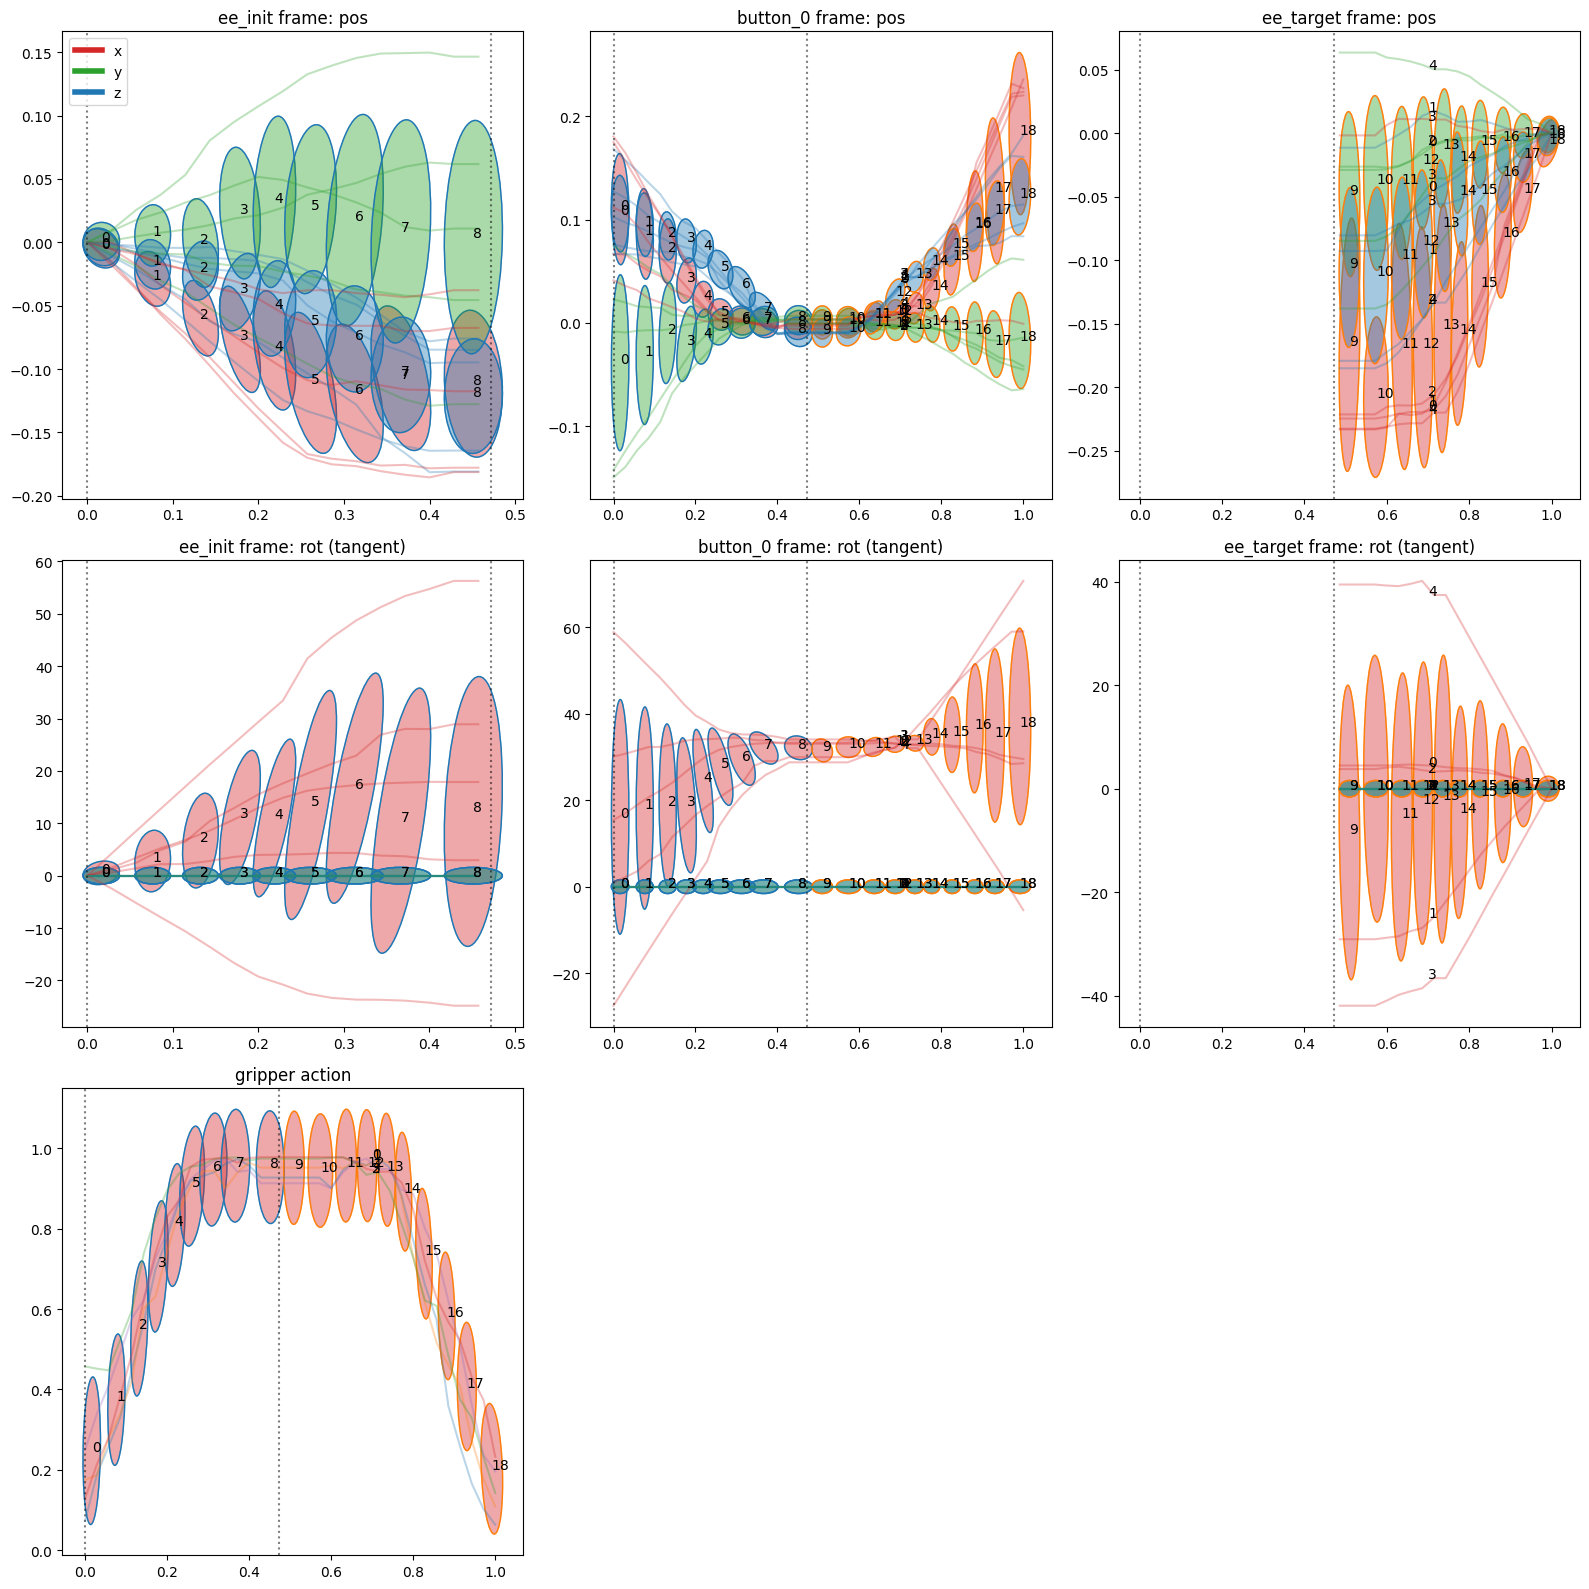

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

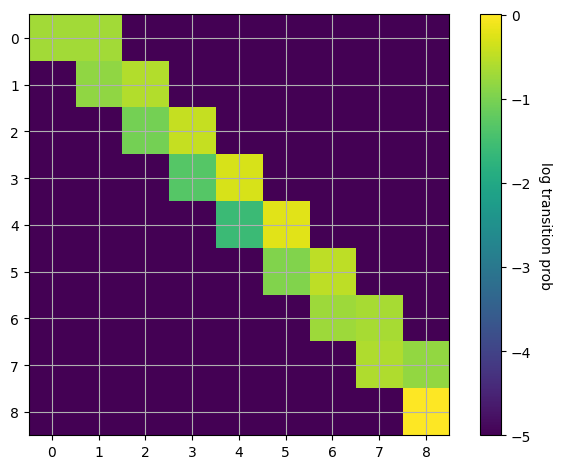

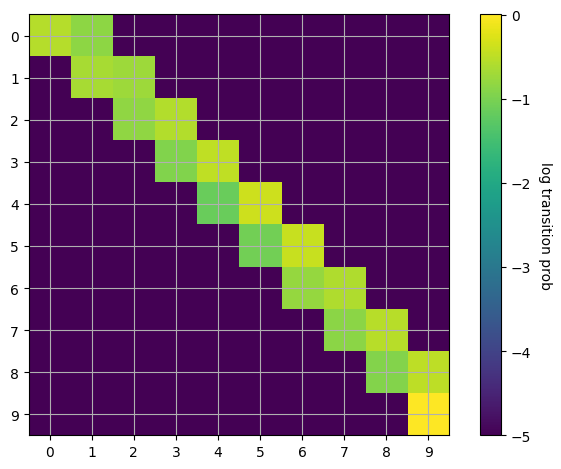

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
agent.save()

2026-07-07 02:36:18.874 | INFO     | heca.misc.logger:info:30 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_left_button
2026-07-07 02:36:18.874 | INFO     | heca.misc.logger:info:30 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_left_button/policy_gt.pt
2026-07-07 02:36:18.874 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [10]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


2026-07-07 02:36:18.909 | INFO     | tapas_gmm_modified.policy.models.tpgmm:reconstruct:3239 - Time-based reconstruction not specified. Auto selected True.
2026-07-07 02:36:24.205 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_cascade_segment_hmms:3343 - Caculated segment transition probabilities: (array([[0.07]]),)
2026-07-07 02:36:24.205 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:36:24.205 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 36 using strategy mean-length.
2026-07-07 02:36:24.207 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity. Should be fixed.
2026-07-07 02:36:24.207 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.207 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:24.212 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.215 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.218 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.221 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.224 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.227 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.230 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.233 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.236 | INFO     | riepybdlib.statistics:set_n

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:24.245 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.253 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.259 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.265 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.272 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.278 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:36:24.278 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 36 using strategy mean-length.
2026-07-07 02:36:24.280 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity.

...

2026-07-07 02:36:24.284 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.288 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.291 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.294 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.297 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.300 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.302 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.304 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.307 | INFO     | riepybdlib.statisti

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:24.315 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.323 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.331 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.339 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.346 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.355 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:24.355 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:24.355 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:24.355 | WARNING  | riepybd

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:24.358 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.358 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.534 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.534 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.693 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.694 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:24.894 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:24.895 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:25.116 | INFO     | riepybdlib.statistics:s

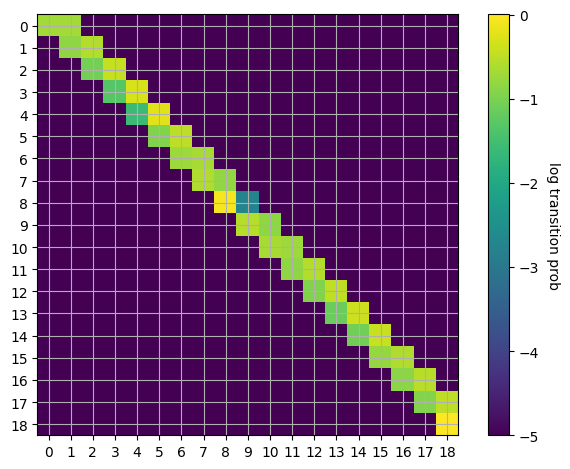

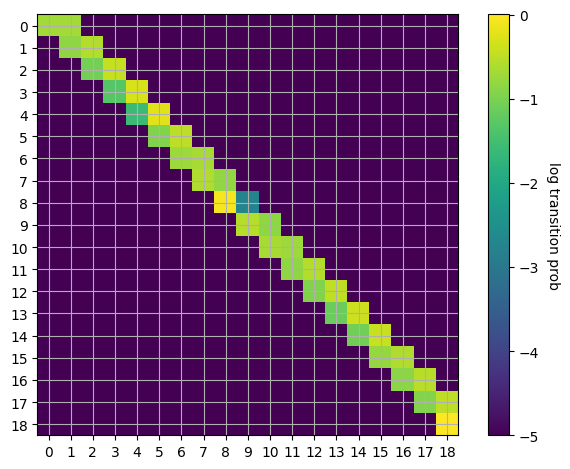

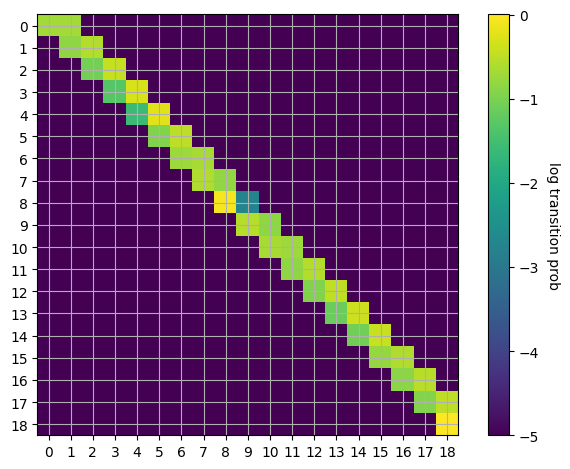

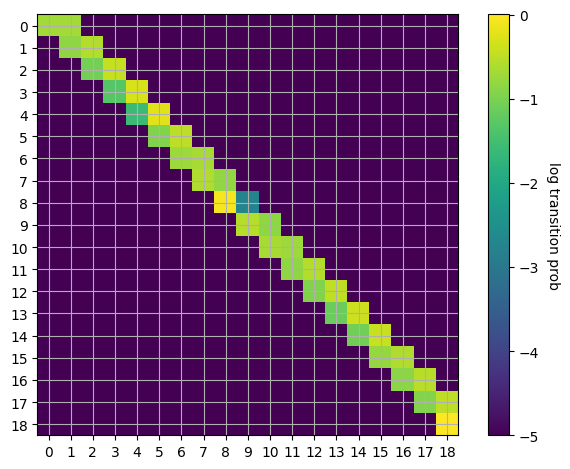

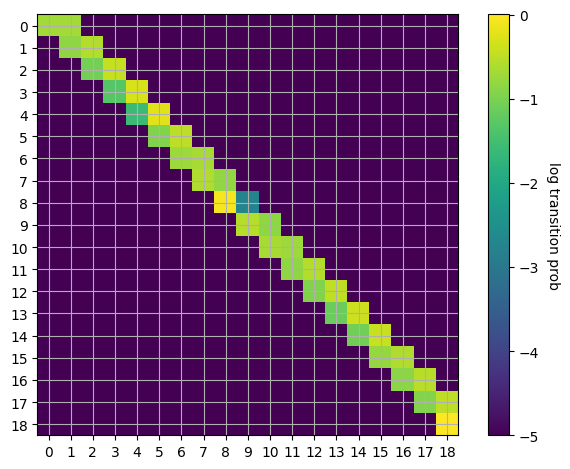

In [11]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2026-07-07 02:36:26.186 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_plot_reconstructions_jointly:4105 - Taking frame origins from demos.


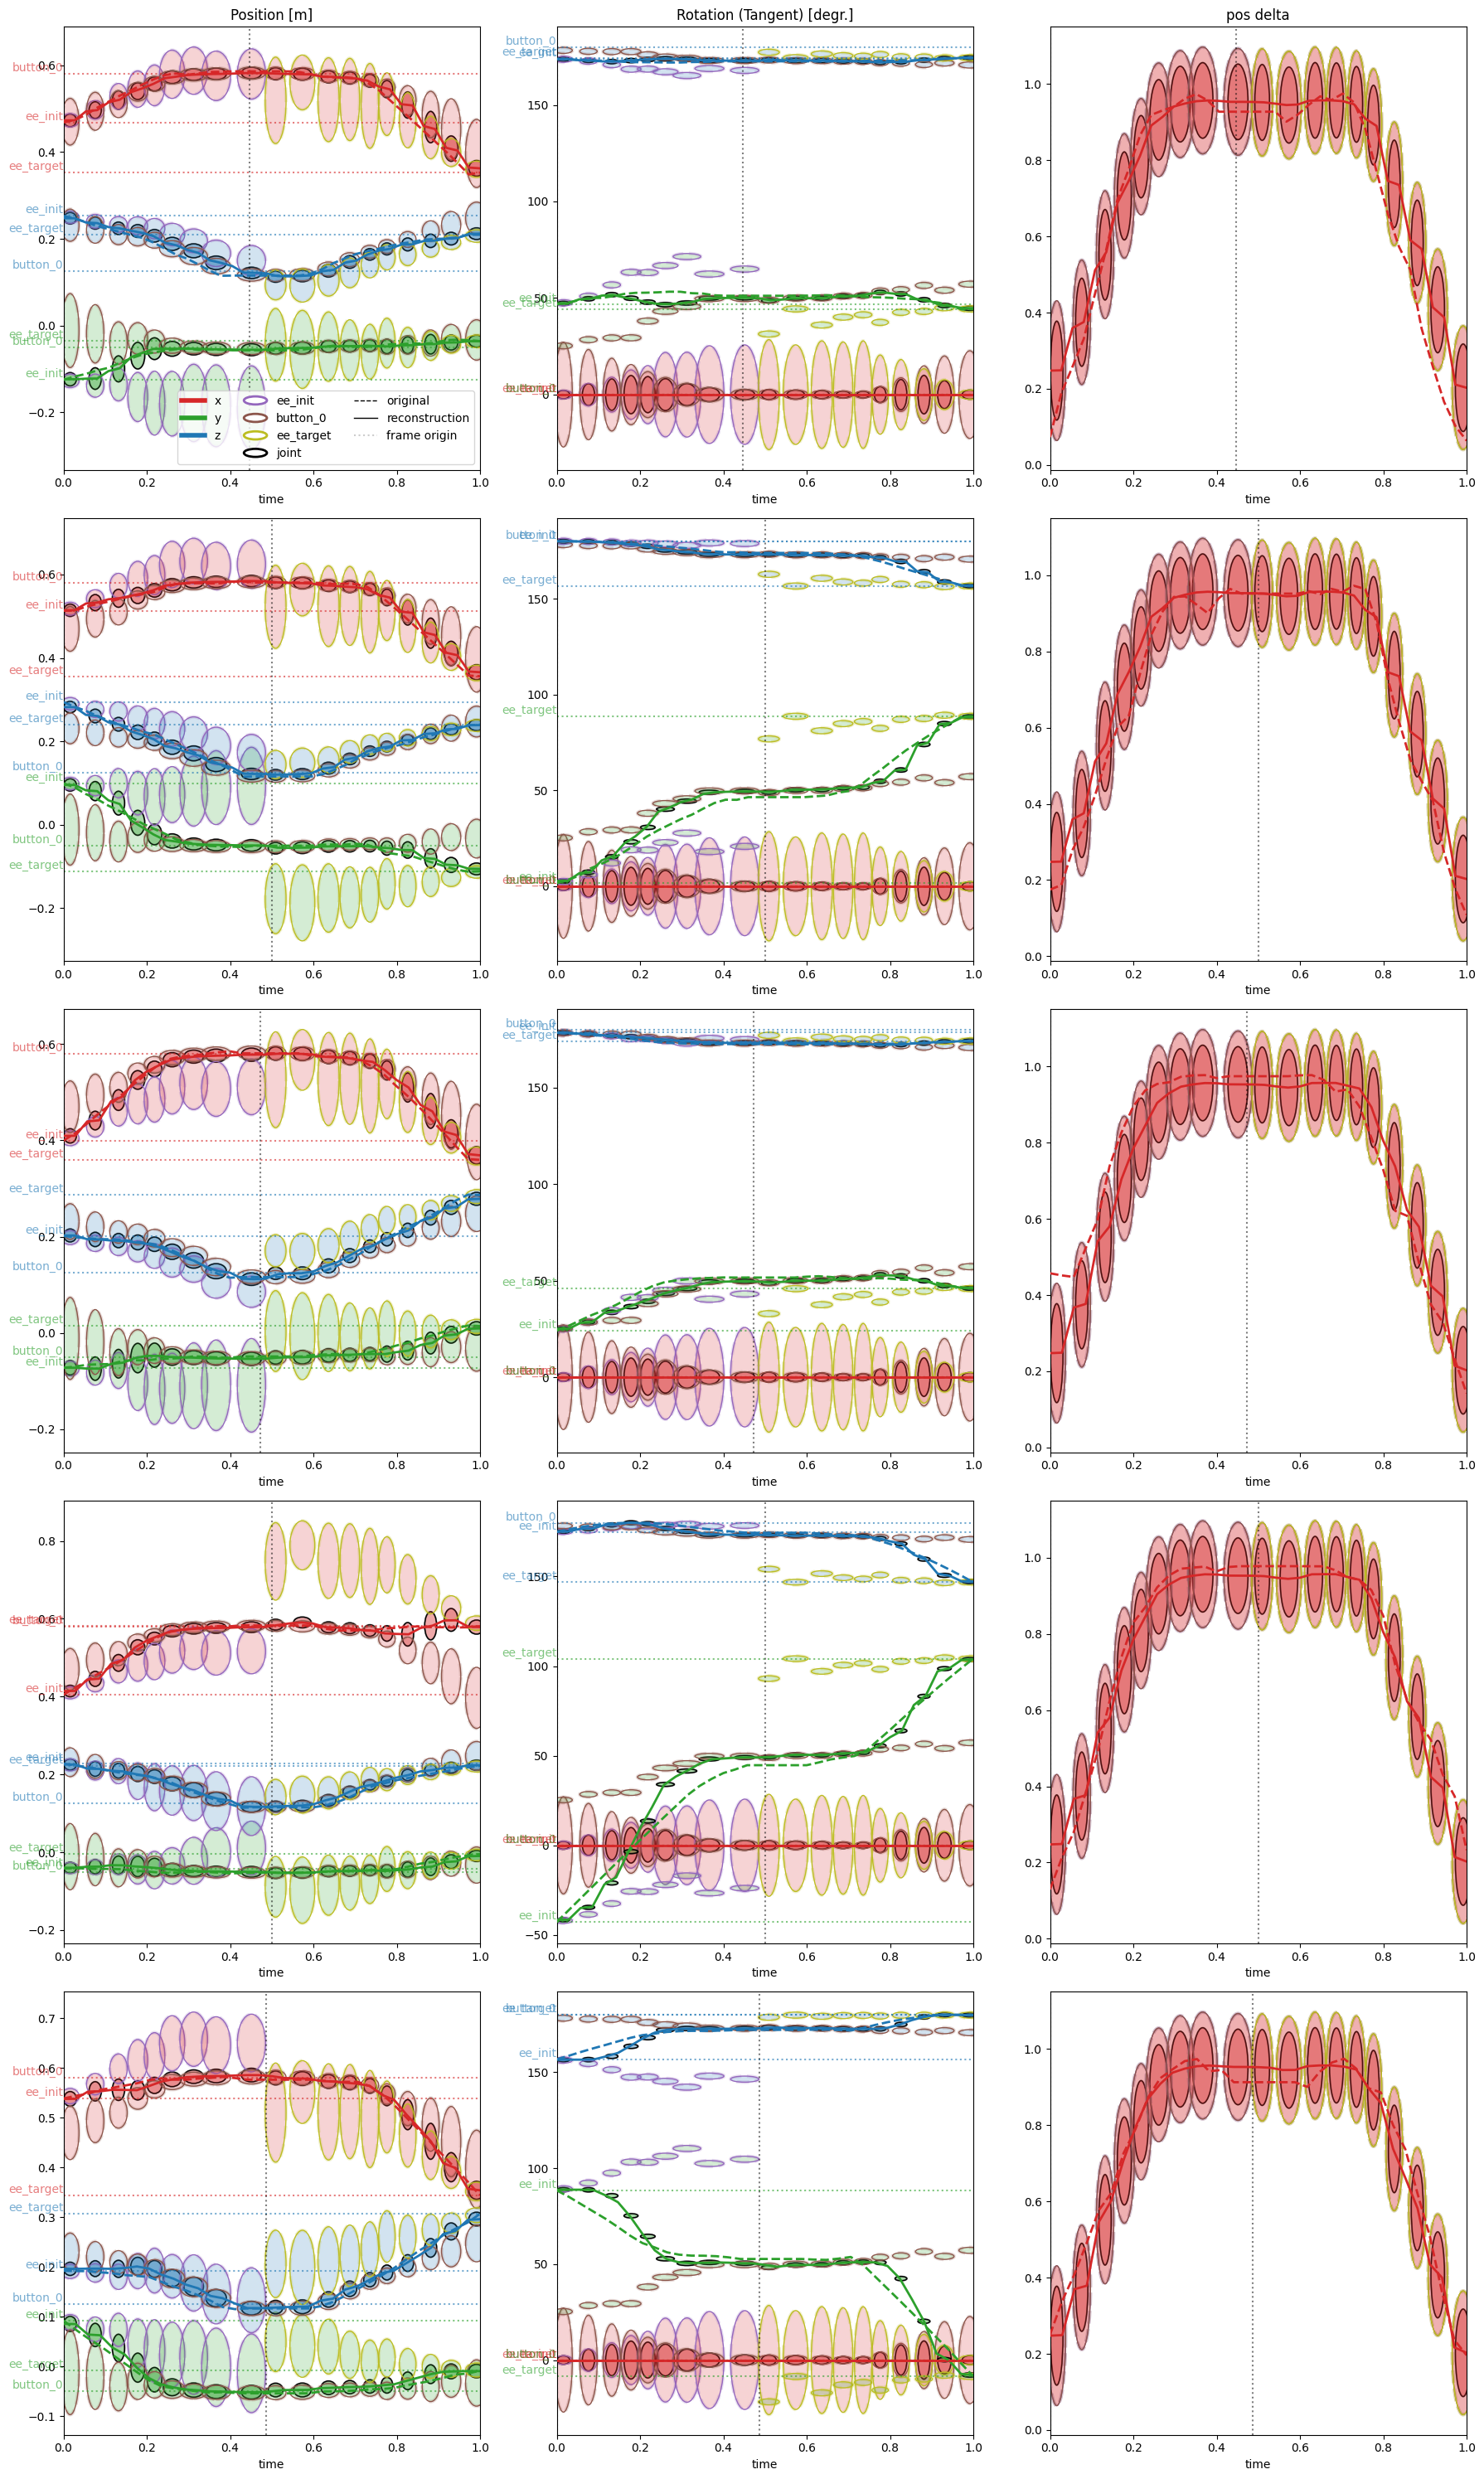

In [12]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [13]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range